In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('C:/Users/fusb1/Desktop/Fraud detecting/data/creditcard.csv')

print("Размер данных")
print(f'строк: {df.shape[0]}')
print(f'колонок: {df.shape[1]}')

#Смотрю размер

Размер данных
строк: 284807
колонок: 31


In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
df.head(5)

#Смотрю как выглядит таблица

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
print(df.isnull().sum().sum())

#Смотрю сколько значений пропущено
#Cмотрю в каких столбцах 
# print(df.isnull().sum().to_string())

0


In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)
print(df[df.columns[:3].append(df.columns[-3:])].describe().round(4))

#Cмотрю статистику, странно есть транзакции в 0 рублей (это не логично)

              Time           V1           V2          V28       Amount        Class
count  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000
mean    94813.8596       0.0000       0.0000      -0.0000      88.3496       0.0017
std     47488.1460       1.9587       1.6513       0.3301     250.1201       0.0415
min         0.0000     -56.4075     -72.7157     -15.4301       0.0000       0.0000
25%     54201.5000      -0.9204      -0.5985      -0.0530       5.6000       0.0000
50%     84692.0000       0.0181       0.0655       0.0112      22.0000       0.0000
75%    139320.5000       1.3156       0.8037       0.0783      77.1650       0.0000
max    172792.0000       2.4549      22.0577      33.8478   25691.1600       1.0000


In [ ]:
zero_amount = df[df['Amount'] == 0]
print(f"Транзакций с суммой 0: {len(zero_amount)}")
print(f"Из них мошеннических: {zero_amount['Class'].sum()}")
print(zero_amount[['Time', 'Amount', 'Class']].head(10))

#Cмотрю статистику по таким транзакциям

Транзакций с суммой 0: 1825
Из них мошеннических: 27
        Time  Amount  Class
383    282.0     0.0      0
514    380.0     0.0      0
534    403.0     0.0      0
541    406.0     0.0      1
575    430.0     0.0      0
936    711.0     0.0      0
1059   804.0     0.0      0
1072   820.0     0.0      0
1170   912.0     0.0      0
1526  1193.0     0.0      0


In [ ]:
v_cols = [f'V{i}' for i in range(1, 29)]
print(df[v_cols].describe().round(4).to_string())

#Cмотрю статистику по V-признакам, они уже приведены к нормализованому виду

                V1           V2           V3           V4           V5           V6           V7           V8           V9          V10          V11          V12          V13          V14          V15          V16          V17          V18          V19          V20          V21          V22          V23          V24          V25          V26          V27          V28
count  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000  284807.0000
mean        0.0000       0.0000      -0.0000       0.0000       0.0000       0.0000      -0.0000       0.0000      -0.0000       0.0000       0.0000      -0.0000       0.0000       0.0000       0.0000       0.0000      -0.0000       0.0000       0.0000       0

In [ ]:
class_counts = df['Class'].value_counts()
print(f"Class 0: {class_counts[0]:,}")
print(f"Class 1: {class_counts[1]:,}")
fraud_percent = class_counts[1] / class_counts.sum() * 100
print(f"Доля мошеннических: {fraud_percent:.4f}%")
ratio = class_counts[0] / class_counts[1]
print(f"Соотношение 1 : {ratio:.0f}")

#Cчитаю процент мошеннических транзакций.

Class 0: 284,315
Class 1: 492
Доля мошеннических: 0.1727%
Соотношение 1 : 578


In [ ]:
normal = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]


print("Обычные:")
print(f"  Средняя сумма: ${normal['Amount'].mean():.2f}")
print(f"  Медианная сумма: ${normal['Amount'].median():.2f}")
print(f"  Минимальная: ${normal['Amount'].min():.2f}")
print(f"  Максимальная: ${normal['Amount'].max():.2f}")
print(f"  Стандартное отклонение: ${normal['Amount'].std():.2f}")

print("\n МОШЕННИЧЕСКИЕ:")
print(f"  Средняя сумма: ${fraud['Amount'].mean():.2f}")
print(f"  Медианная сумма: ${fraud['Amount'].median():.2f}")
print(f"  Минимальная: ${fraud['Amount'].min():.2f}")
print(f"  Максимальная: ${fraud['Amount'].max():.2f}")
print(f"  Стандартное отклонение: ${fraud['Amount'].std():.2f}")

print(f"\n Средняя сумма мошеннических выше на: ${fraud['Amount'].mean() - normal['Amount'].mean():.2f}")
print(f" Медианная сумма мошеннических выше на: ${fraud['Amount'].median() - normal['Amount'].median():.2f}")

# Средняя сума мошеннических транзакций выше обычных, а медиана ниже.
# Предположение: "у мошенников большой разброс сумм"
# Большинство мошеннических транзакций меньше $9.25, но есть несколько крупных, которые тянут среднее вверх

Обычные:
  Средняя сумма: $88.29
  Медианная сумма: $22.00
  Минимальная: $0.00
  Максимальная: $25691.16
  Стандартное отклонение: $250.11

 МОШЕННИЧЕСКИЕ:
  Средняя сумма: $122.21
  Медианная сумма: $9.25
  Минимальная: $0.00
  Максимальная: $2125.87
  Стандартное отклонение: $256.68

 Средняя сумма мошеннических выше на: $33.92
 Медианная сумма мошеннических выше на: $-12.75


C:\Users\fusb1\AppData\Local\Temp\ipykernel_10848\2310528441.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([normal['Amount'], fraud['Amount']],


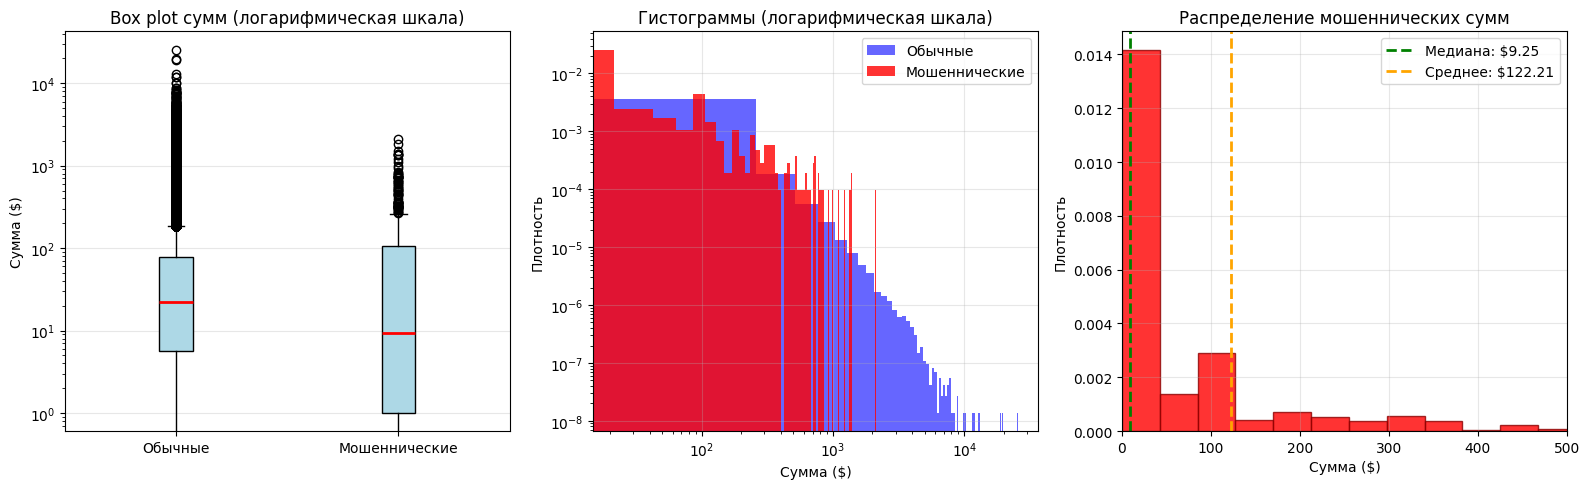

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# График 1: 
axes[0].boxplot([normal['Amount'], fraud['Amount']], 
                labels=['Обычные', 'Мошеннические'],
                patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[0].set_ylabel('Сумма ($)')
axes[0].set_title('Box plot сумм (логарифмическая шкала)')
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3, axis='y')

# График 2:
axes[1].hist(normal['Amount'], bins=100, alpha=0.6, label='Обычные', density=True, color='blue')
axes[1].hist(fraud['Amount'], bins=100, alpha=0.8, label='Мошеннические', density=True, color='red')
axes[1].set_xlabel('Сумма ($)')
axes[1].set_ylabel('Плотность')
axes[1].set_title('Гистограммы (логарифмическая шкала)')
axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# График 3:
axes[2].hist(fraud['Amount'], bins=50, alpha=0.8, color='red', edgecolor='darkred', density=True)
axes[2].set_xlabel('Сумма ($)')
axes[2].set_ylabel('Плотность')
axes[2].set_title('Распределение мошеннических сумм')
axes[2].set_xlim(0, 500)
axes[2].grid(True, alpha=0.3)

axes[2].axvline(fraud['Amount'].median(), color='green', linestyle='--', linewidth=2, 
                label=f'Медиана: ${fraud["Amount"].median():.2f}')
axes[2].axvline(fraud['Amount'].mean(), color='orange', linestyle='--', linewidth=2, 
                label=f'Среднее: ${fraud["Amount"].mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

#Графики распределений сумм транзакций

In [ ]:
def count_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    return outliers, len(outliers)


normal_outliers, normal_count = count_outliers(normal['Amount'])
print("ОБЫЧНЫЕ ТРАНЗАКЦИИ")
print(f"Всего транзакций: {len(normal):,}")
print(f"Выбросов (кружков): {normal_count:,}")
print(f"Доля выбросов: {normal_count / len(normal) * 100:.2f}%")
print(f"Минимальный выброс: ${normal_outliers.min():.2f}")
print(f"Максимальный выброс: ${normal_outliers.max():.2f}")
print(f"Средний выброс: ${normal_outliers.mean():.2f}")


print("\n\nМОШЕННИЧЕСКИЕ ТРАНЗАКЦИИ")
fraud_outliers, fraud_count = count_outliers(fraud['Amount'])
print(f"Всего транзакций: {len(fraud):,}")
print(f"Выбросов (кружков): {fraud_count:,}")
print(f"Доля выбросов: {fraud_count / len(fraud) * 100:.2f}%")
print(f"Минимальный выброс: ${fraud_outliers.min():.2f}")
print(f"Максимальный выброс: ${fraud_outliers.max():.2f}")
print(f"Средний выброс: ${fraud_outliers.mean():.2f}")

#Проверяю что выбросов нормальное количество, относительно количества данных

ОБЫЧНЫЕ ТРАНЗАКЦИИ
Всего транзакций: 284,315
Выбросов (кружков): 31,862
Доля выбросов: 11.21%
Минимальный выброс: $184.15
Максимальный выброс: $25691.16
Средний выброс: $510.90


МОШЕННИЧЕСКИЕ ТРАНЗАКЦИИ
Всего транзакций: 492
Выбросов (кружков): 69
Доля выбросов: 14.02%
Минимальный выброс: $270.00
Максимальный выброс: $2125.87
Средний выброс: $625.55


Обычные:
  1%: $0.12
  5%: $0.92
  10%: $1.00
  20%: $3.58
  25%: $5.65
  50%: $22.00
  60%: $37.00
  75%: $77.05
  80%: $100.00
  90%: $202.72
  95%: $364.41
  99%: $1016.97
  100%: $25691.16

Мошеннические:
  1%: $0.00
  5%: $0.00
  10%: $0.76
  20%: $1.00
  25%: $1.00
  50%: $9.25
  60%: $39.99
  75%: $105.89
  80%: $152.34
  90%: $346.75
  95%: $640.90
  99%: $1357.43
  100%: $2125.87


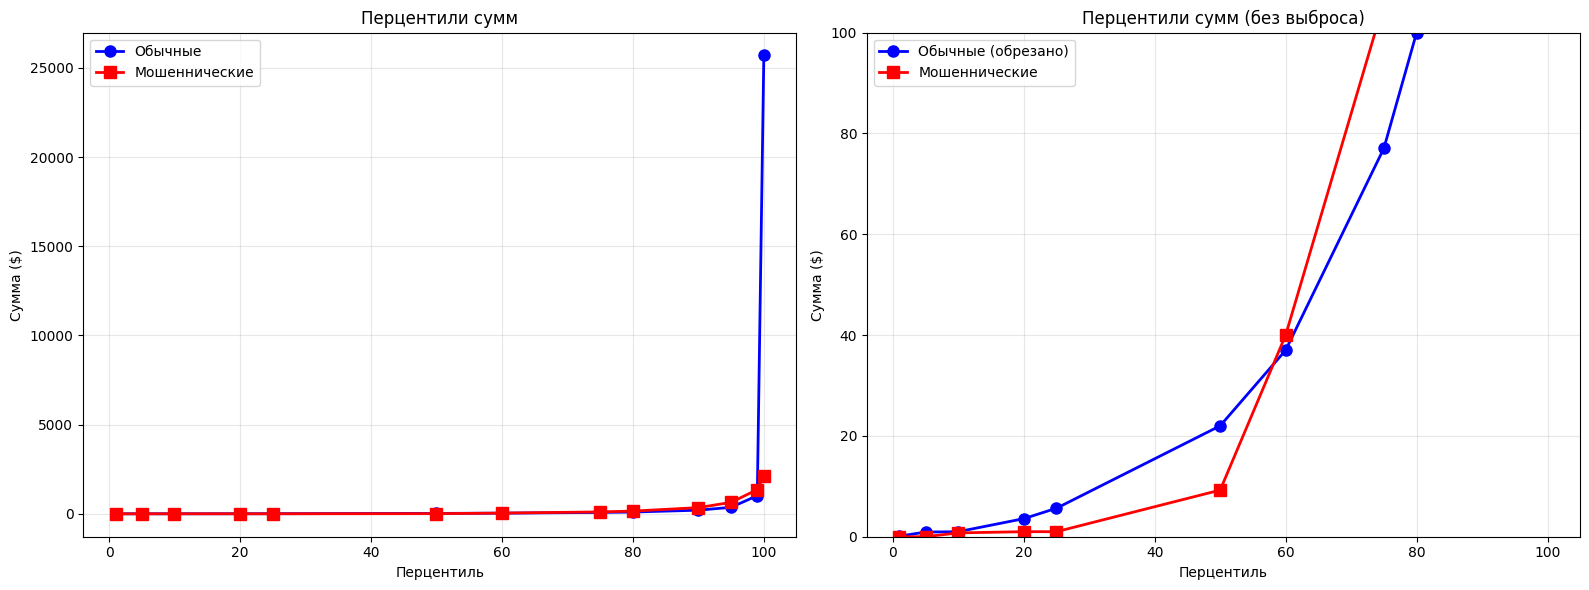

In [43]:
percentiles = [1, 5, 10, 20, 25, 50, 60, 75, 80, 90, 95, 99, 100]

print("Обычные:")
normal_percentiles = np.percentile(normal['Amount'], percentiles)
for p, val in zip(percentiles, normal_percentiles):
    print(f"  {p}%: ${val:.2f}")

print("\nМошеннические:")
fraud_percentiles = np.percentile(fraud['Amount'], percentiles)
for p, val in zip(percentiles, fraud_percentiles):
    print(f"  {p}%: ${val:.2f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(percentiles, normal_percentiles, 'o-', label='Обычные', linewidth=2, color='blue', markersize=8)
ax1.plot(percentiles, fraud_percentiles, 's-', label='Мошеннические', linewidth=2, color='red', markersize=8)
ax1.set_xlabel('Перцентиль')
ax1.set_ylabel('Сумма ($)')
ax1.set_title('Перцентили сумм')
ax1.legend()
ax1.grid(True, alpha=0.3)

normal_percentiles_trimmed = normal_percentiles.copy()
normal_percentiles_trimmed[-1] = normal_percentiles[-2]

ax2.plot(percentiles, normal_percentiles_trimmed, 'o-', label='Обычные (обрезано)', linewidth=2, color='blue', markersize=8)
ax2.plot(percentiles, fraud_percentiles, 's-', label='Мошеннические', linewidth=2, color='red', markersize=8)
ax2.set_xlabel('Перцентиль')
ax2.set_ylabel('Сумма ($)')
ax2.set_title('Перцентили сумм (без выброса)')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# перцентили сумм
# До 50% (медианы) — обычные крупнее
# После 60% — мошеннические крупнее
# Вывод: воруют много по чуть-чуть, но иногда воруют и по крупному

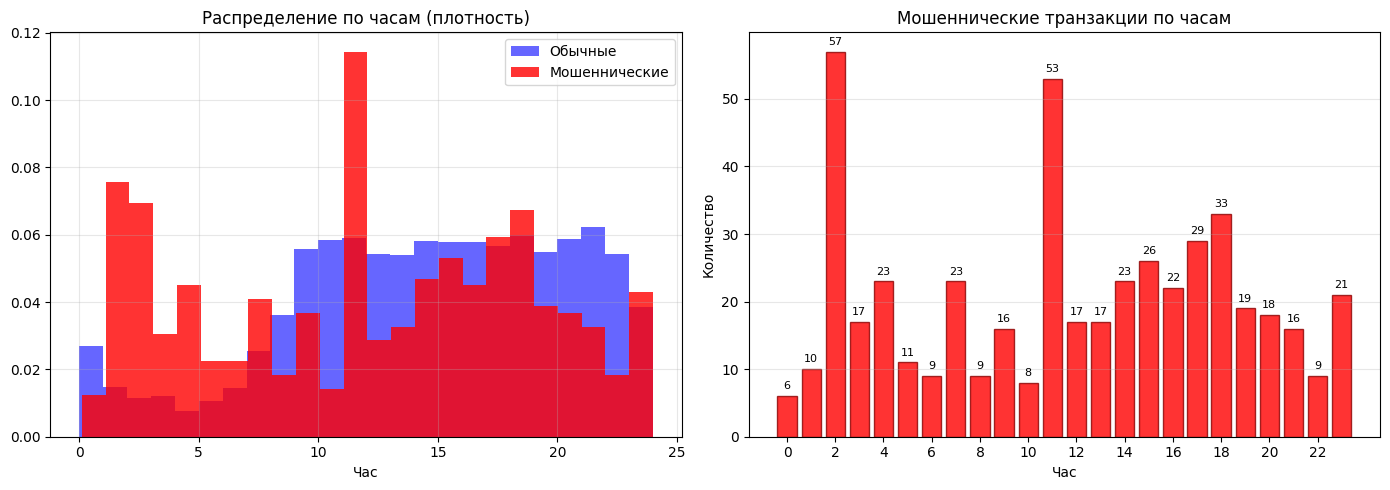

Часы с мошенничествами (>5):
  00:00 - 6
  01:00 - 10
  02:00 - 57
  03:00 - 17
  04:00 - 23
  05:00 - 11
  06:00 - 9
  07:00 - 23
  08:00 - 9
  09:00 - 16
  10:00 - 8
  11:00 - 53
  12:00 - 17
  13:00 - 17
  14:00 - 23
  15:00 - 26
  16:00 - 22
  17:00 - 29
  18:00 - 33
  19:00 - 19
  20:00 - 18
  21:00 - 16
  22:00 - 9
  23:00 - 21


In [ ]:
df['Hour'] = (df['Time'] / 3600) % 24

normal_hours = df[df['Class'] == 0]['Hour']
fraud_hours = df[df['Class'] == 1]['Hour']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(normal_hours, bins=24, alpha=0.6, label='Обычные', density=True, color='blue')
axes[0].hist(fraud_hours, bins=24, alpha=0.8, label='Мошеннические', density=True, color='red')
axes[0].set_xlabel('Час')
axes[0].set_title('Распределение по часам (плотность)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


counts = []
for hour in range(24):
    count = sum((fraud_hours >= hour) & (fraud_hours < hour + 1))
    counts.append(count)

axes[1].bar(range(24), counts, color='red', edgecolor='darkred', alpha=0.8)
axes[1].set_xlabel('Час')
axes[1].set_ylabel('Количество')
axes[1].set_title('Мошеннические транзакции по часам')
axes[1].set_xticks(range(0, 24, 2))
axes[1].grid(True, alpha=0.3, axis='y')

for i, count in enumerate(counts):
    if count > 0:
        axes[1].text(i, count + 1, str(count), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print("Часы с мошенничествами (>5):")
for hour in range(24):
    if counts[hour] > 5:
        print(f"  {hour:02d}:00 - {counts[hour]}")


#Смотрю есть ли кореляция между мошенническими транзакциями и времением суток.
# Пики:
#1. 02:00 (57)  — глубокая ночь
#2. 11:00 (53)  — перед обедом
#3. 18:00 (33)  — вечер


In [ ]:
df['Amount_log'] = np.log1p(df['Amount'])
df['Amount_small'] = (df['Amount'] < 10).astype(int)
df['Amount_large'] = (df['Amount'] > 200).astype(int)
df['Hour'] = (df['Time'] / 3600) % 24
df['Is_night'] = ((df['Hour'] >= 1) & (df['Hour'] <= 4)).astype(int)
df['Is_lunch'] = ((df['Hour'] >= 11) & (df['Hour'] <= 13)).astype(int)

#Создаю дополнительные признаки

In [ ]:


v_comparison = pd.DataFrame({
    'Признак': v_cols,
    'Среднее (обычные)': normal[v_cols].mean().values,
    'Среднее (мошеннические)': fraud[v_cols].mean().values,
    'Разница': fraud[v_cols].mean().values - normal[v_cols].mean().values
})
v_comparison['|Разница|'] = v_comparison['Разница'].abs()
v_comparison = v_comparison.sort_values('|Разница|', ascending=False)
print(v_comparison.head(20).to_string(index=False))

#Cмотрю у каких признаков большая разница средних мошеннических и обычных транзакций

Признак  Среднее (обычные)  Среднее (мошеннические)   Разница  |Разница|
     V3           0.012171                -7.033281 -7.045452   7.045452
    V14           0.012064                -6.971723 -6.983787   6.983787
    V17           0.011535                -6.665836 -6.677371   6.677371
    V12           0.010832                -6.259393 -6.270225   6.270225
    V10           0.009824                -5.676883 -5.686707   5.686707
     V7           0.009637                -5.568731 -5.578368   5.578368
     V1           0.008258                -4.771948 -4.780206   4.780206
     V4          -0.007860                 4.542029  4.549889   4.549889
    V16           0.007164                -4.139946 -4.147110   4.147110
    V11          -0.006576                 3.800173  3.806749   3.806749
     V2          -0.006271                 3.623778  3.630049   3.630049
     V5           0.005453                -3.151225 -3.156678   3.156678
     V9           0.004467                -2.581123

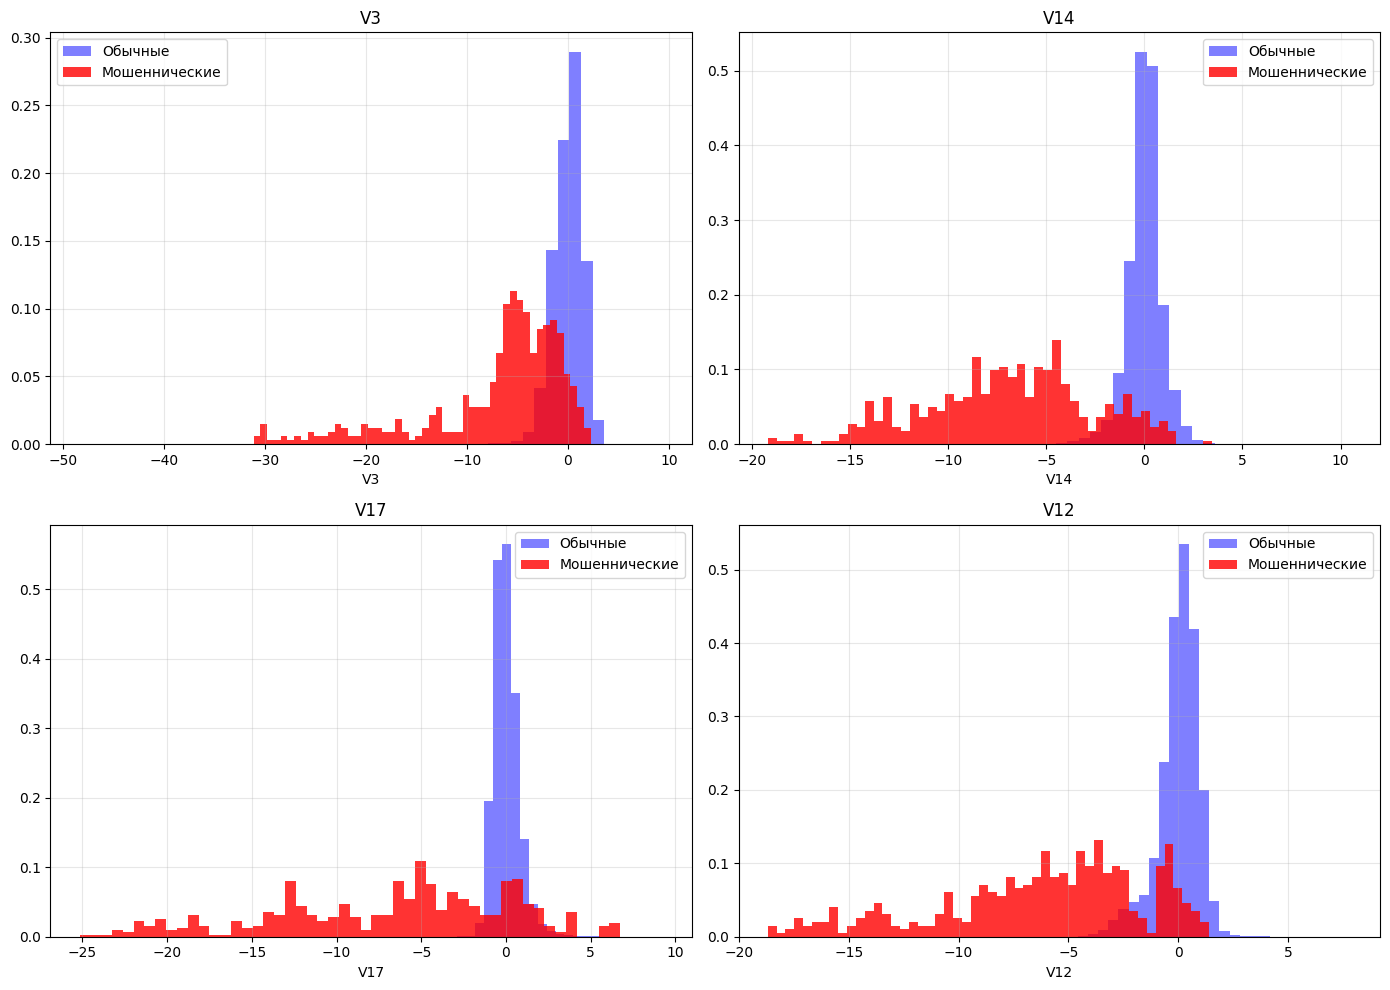

In [44]:
top_features = v_comparison.head(4)['Признак'].tolist()
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, feature in enumerate(top_features):
    axes[i].hist(normal[feature], bins=50, alpha=0.5, label='Обычные', density=True, color='blue')
    axes[i].hist(fraud[feature], bins=50, alpha=0.8, label='Мошеннические', density=True, color='red')
    axes[i].set_xlabel(feature)
    axes[i].set_title(f'{feature}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
correlations = df[v_cols].corrwith(df['Class']).abs().sort_values(ascending=False)

print("Топ-10:")
for i, (feature, corr) in enumerate(correlations.head(10).items(), 1):
    print(f"  {i}. {feature}: {corr:.4f}")

print("Наименьшие:")
for i, (feature, corr) in enumerate(correlations.tail(5).items(), 1):
    print(f"  {i}. {feature}: {corr:.4f}")

#Cчитаю корреляцию между каждым V-признаком (V1-V28) и целевой переменной Class

Топ-10:
  1. V17: 0.3265
  2. V14: 0.3025
  3. V12: 0.2606
  4. V10: 0.2169
  5. V16: 0.1965
  6. V3: 0.1930
  7. V7: 0.1873
  8. V11: 0.1549
  9. V4: 0.1334
  10. V18: 0.1115
Наименьшие:
  1. V26: 0.0045
  2. V15: 0.0042
  3. V25: 0.0033
  4. V23: 0.0027
  5. V22: 0.0008


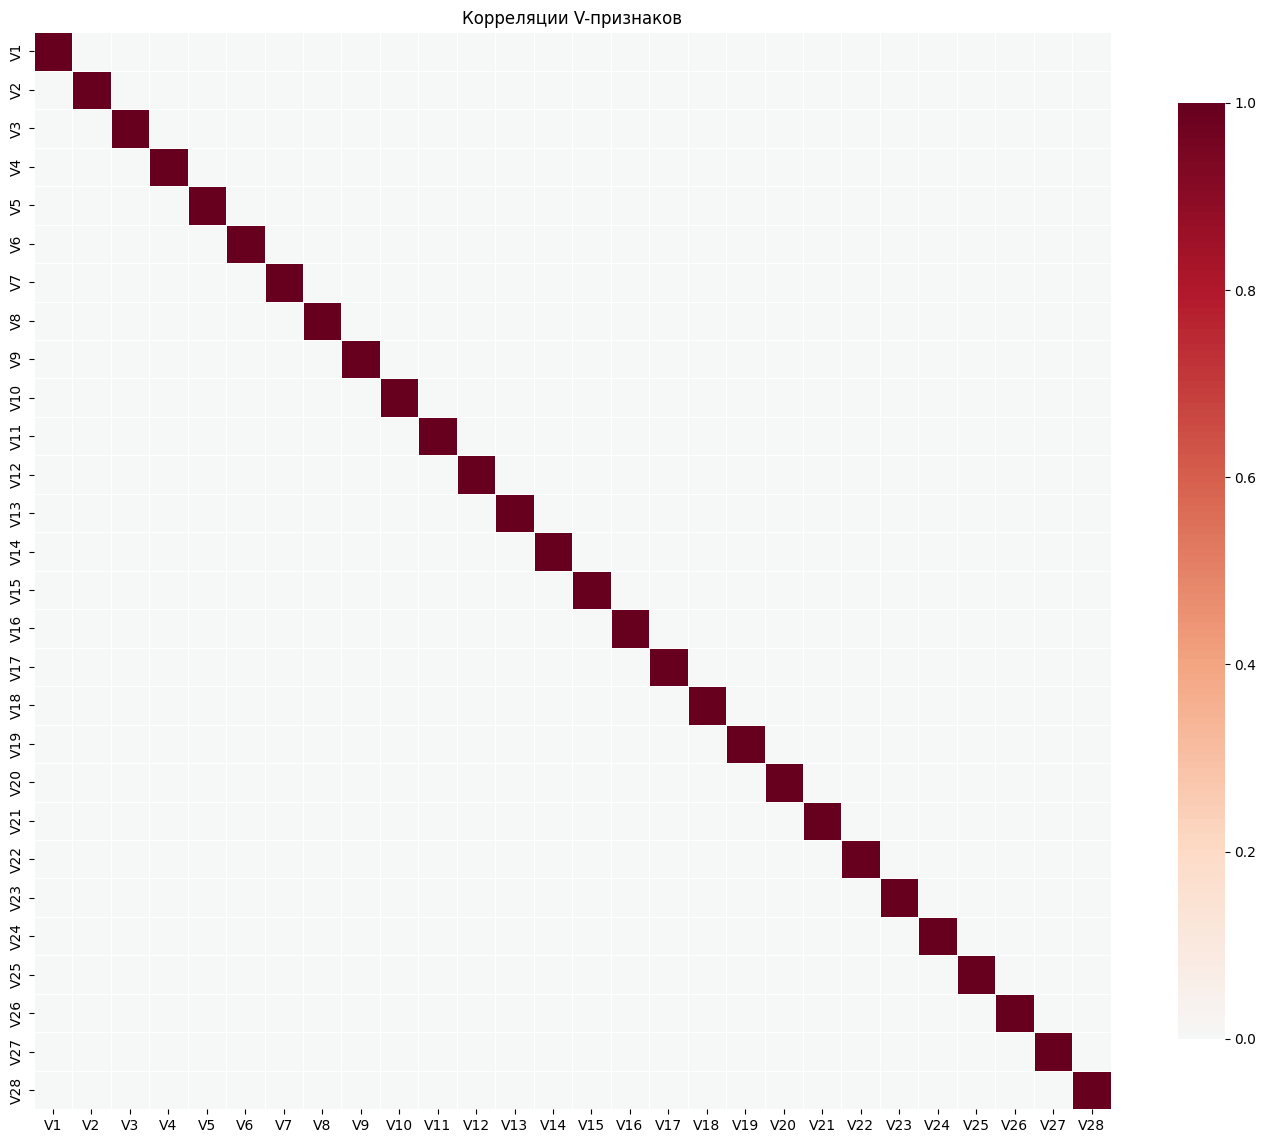

Нет сильных корреляций >0.7


In [ ]:
plt.figure(figsize=(14, 12))
corr_matrix = df[v_cols].corr()
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Корреляции V-признаков')
plt.tight_layout()
plt.show()

strong_pairs = []
for i in range(len(v_cols)):
    for j in range(i+1, len(v_cols)):
        corr = corr_matrix.iloc[i, j]
        if abs(corr) > 0.7:
            strong_pairs.append((v_cols[i], v_cols[j], corr))

if strong_pairs:
    for pair in strong_pairs:
        print(f"{pair[0]} и {pair[1]}: {pair[2]:.4f}")
else:
    print("Нет сильных корреляций >0.7")

#Если два признака сильно коррелируют (>0.7), это значит, что они несут одинаковую информацию. 
#В таком случае один из них можно удалить.

In [ ]:
def find_outliers(data, feature):
    mean = data[feature].mean()
    std = data[feature].std()
    outliers = data[(data[feature] > mean + 3*std) | (data[feature] < mean - 3*std)]
    return len(outliers)

print("Выбросы в мошеннических транзакциях:")
for feature in v_cols[:]:
    outliers_count = find_outliers(fraud, feature)
    if outliers_count > 0:
        print(f"  {feature}: {outliers_count} ({outliers_count/len(fraud)*100:.1f}%)")


#V22, V23, V25, V15, V26: корреляция <0.01, выбросы есть (10, 12, 3, 2, 2)
#Но эти выбросы, скорее всего, те же самые 10-15 транзакций, которые аномальны и по другим признакам
#Поэтому удаляем — важную информацию уже несут другие признаки

Выбросы в мошеннических транзакциях:
  V1: 15 (3.0%)
  V2: 9 (1.8%)
  V3: 10 (2.0%)
  V5: 6 (1.2%)
  V6: 8 (1.6%)
  V7: 10 (2.0%)
  V8: 10 (2.0%)
  V9: 4 (0.8%)
  V10: 8 (1.6%)
  V11: 1 (0.2%)
  V15: 2 (0.4%)
  V20: 5 (1.0%)
  V21: 10 (2.0%)
  V22: 10 (2.0%)
  V23: 12 (2.4%)
  V24: 2 (0.4%)
  V25: 3 (0.6%)
  V26: 2 (0.4%)
  V27: 10 (2.0%)
  V28: 4 (0.8%)


Удаляем 5 признаков
Оставляем 10 важных + Amount + Time


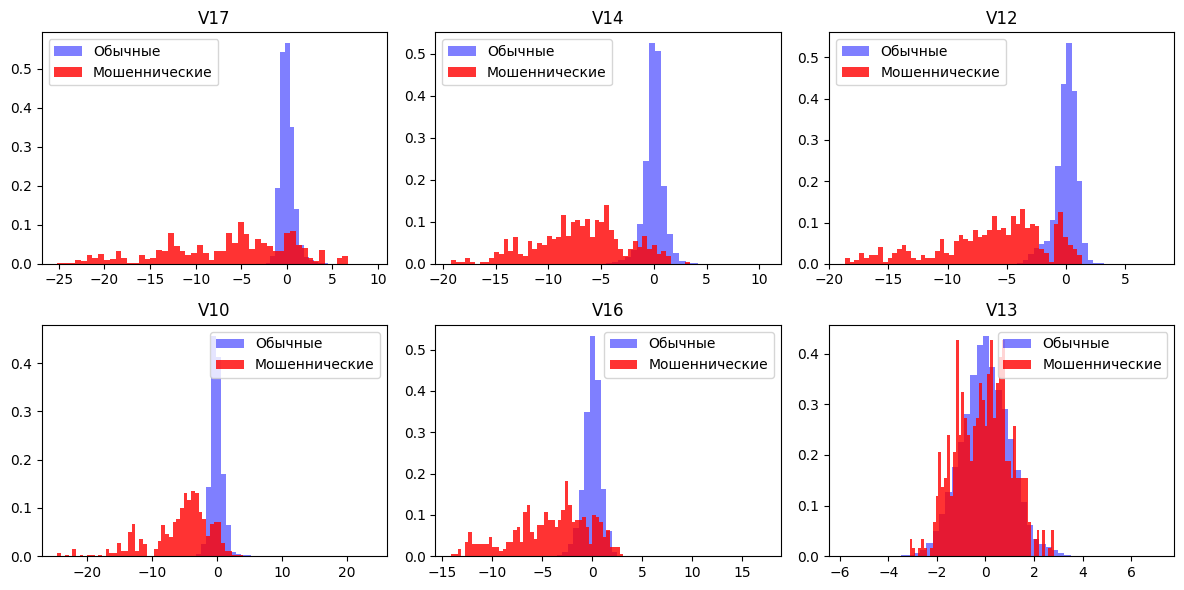

In [51]:
useless_features = ['V22', 'V23', 'V25', 'V15', 'V26']
important_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']

print(f"Удаляем {len(useless_features)} признаков")
print(f"Оставляем {len(important_features)} важных + Amount + Time")

top_features_vis = ['V17', 'V14', 'V12', 'V10', 'V16', 'V13']
plt.figure(figsize=(12, 6))
for i, feature in enumerate(top_features_vis):
    plt.subplot(2, 3, i+1)
    plt.hist(normal[feature], bins=50, alpha=0.5, label='Обычные', density=True, color='blue')
    plt.hist(fraud[feature], bins=50, alpha=0.8, label='Мошеннические', density=True, color='red')
    plt.title(f'{feature}')
    plt.legend()
plt.tight_layout()
plt.show()

In [57]:
if 'Hour' not in df.columns:
    df['Hour'] = (df['Time'] / 3600) % 24

df_sorted = df.sort_values('Time')
important_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'V3', 'V7', 'V11', 'V4', 'V18']
features = important_features + ['Amount', 'Hour', 'Amount_log', 'Amount_small', 'Amount_large', 'Is_night', 'Is_lunch']

missing_features = [f for f in features if f not in df_sorted.columns]
if missing_features:
    print(f"Отсутствуют: {missing_features}")
else:
    print("Все признаки на месте")

X = df_sorted[features]
y = df_sorted['Class']


split_idx = int(len(X) * 0.7)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]


print(f"Train: {len(X_train)} транзакций, мошеннических: {y_train.sum()}")
print(f"Test: {len(X_test)} транзакций, мошеннических: {y_test.sum()}")


#Для начала добавил 10 лучших признаков + собственные, смотрю что будет

Все признаки на месте
Train: 199364 транзакций, мошеннических: 384
Test: 85443 транзакций, мошеннических: 108


In [ ]:
import joblib
import os

data_path = 'C:/Users/fusb1/Desktop/Fraud detecting/data/'

joblib.dump(X_train, data_path + 'X_train.pkl')
joblib.dump(X_test, data_path + 'X_test.pkl')
joblib.dump(y_train, data_path + 'y_train.pkl')
joblib.dump(y_test, data_path + 'y_test.pkl')

print(f"   X_train: {X_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   Признаков: {len(X_train.columns)}")

#Сохранил обучающую матрицу

   X_train: (199364, 17)
   X_test: (85443, 17)
   Признаков: 17
